# Fig: run time speed

project = ```iP-VAE```, host = ```any```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


project_name = '_IterativeVAE'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def overall_perf(x, name):
    portion_zeros = x['portion_zeros_all'][name]
    r2 = x['r2_all'][name].clip(0, 1)
    euc_dist = np.sqrt(
        (1 - r2) ** 2 +
        (1-portion_zeros) ** 2
    )
    return euc_dist

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_dekel/runtime')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03')

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(5, 4)

## Load results

In [4]:
import dill


amortized_bsize1 = 'amortized_r2_vs_time_per_sample_bsize1.pkl'
iterative_bsize1 = 'r2_vs_time_per_sample_bsize1.pkl'
amortized_bsize10000 = 'amortized_r2_vs_time_per_sample_bsize10000.pkl'
iterative_bsize10000 = 'r2_vs_time_per_sample_bsize10000.pkl'

amortized_bsize1 = dill.load(open(pjoin(results_dir, amortized_bsize1), 'rb'))
iterative_bsize1 = dill.load(open(pjoin(results_dir, iterative_bsize1), 'rb'))
amortized_bsize10000 = dill.load(open(pjoin(results_dir, amortized_bsize10000), 'rb'))
iterative_bsize10000 = dill.load(open(pjoin(results_dir, iterative_bsize10000), 'rb'))


for k, v in amortized_bsize10000["timestamps_all"].items():
    amortized_bsize10000["timestamps_all"][k] = v * 10000

## Plot

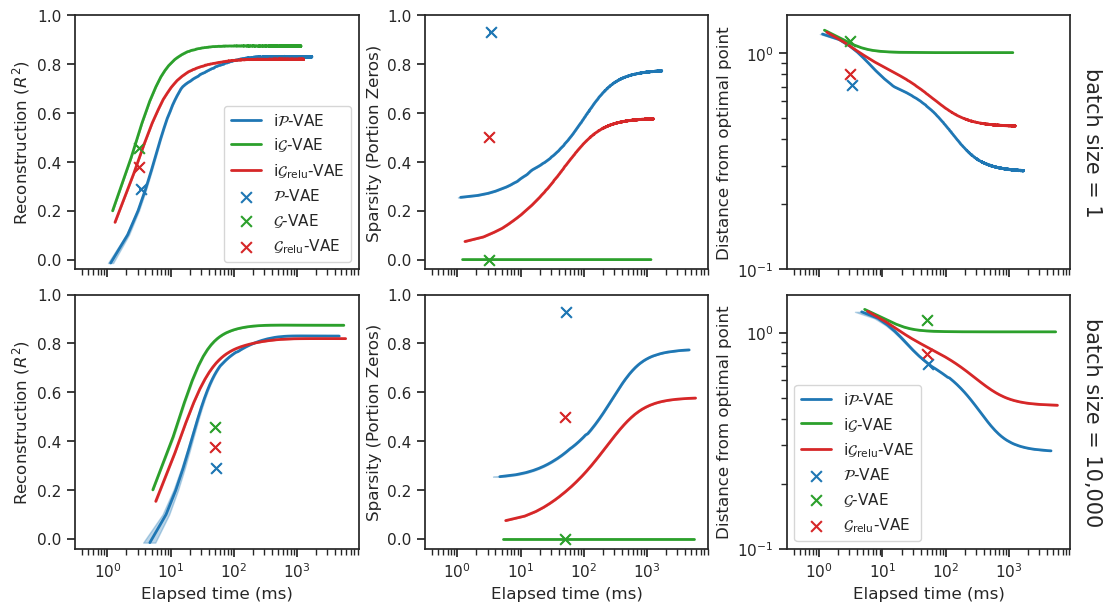

In [17]:
# Controls for axis scales
xscale = 'log'
yscale_r2 = 'linear'
yscale_sparsity = 'linear'
yscale_distance = 'log'

# Styling
colors = {k: pal_models[k] for k in ['poisson', 'gaussian', 'gaussian+relu']}
labels = {
    'poisson': r"i$\mathcal{P}$-VAE",
    "gaussian": r"i$\mathcal{G}$-VAE",
    "gaussian+relu": r"i$\mathcal{G}_\text{relu}$-VAE",
}
labels_am = {
    'poisson': r"$\mathcal{P}$-VAE",
    "gaussian": r"$\mathcal{G}$-VAE",
    "gaussian+relu": r"$\mathcal{G}_\text{relu}$-VAE",
}

def _plot_panel(ax, iter_pack, amort_pack, y_mode, ylabel, yscale='linear',
                add_yerr=False, legend_loc='none', xscale='linear',
                y_fixed=None, set_xlabel=False):
    """
    y_mode in {"r2", "sparsity", "distance"}
    y_fixed: tuple like (ymin, ymax) to force y-limits for this panel, or None to auto/logic below
    set_xlabel: whether to add the shared x-axis label text on this specific subplot
    """

    # choose how to get y
    def get_y_iter(kind):
        if y_mode == "r2":
            return iter_pack['r2_all'][kind].mean(0)
        elif y_mode == "sparsity":
            return iter_pack['portion_zeros_all'][kind].mean(0)
        elif y_mode == "distance":
            return overall_perf(iter_pack, kind).mean(0)
        else:
            raise ValueError("bad y_mode")

    def get_y_amort(kind):
        if y_mode == "r2":
            return amort_pack['r2_all'][kind].mean()
        elif y_mode == "sparsity":
            return amort_pack['portion_zeros_all'][kind].mean()
        elif y_mode == "distance":
            return overall_perf(amort_pack, kind).mean()
        else:
            raise ValueError("bad y_mode")

    def get_yerr_amort(kind):
        if not add_yerr:
            return None
        if y_mode == "r2":
            arr = amort_pack['r2_all'][kind]
        elif y_mode == "sparsity":
            arr = amort_pack['portion_zeros_all'][kind]
        elif y_mode == "distance":
            arr = overall_perf(amort_pack, kind)
        return arr.std() / np.sqrt(arr.shape[0])

    # iterative curves with x-STE ribbons
    for kind in ["poisson", "gaussian", "gaussian+relu"]:
        T = iter_pack['timestamps_all'][kind].cumsum(1)
        x_mu = T.mean(0)
        x_ste = T.std(0) / np.sqrt(T.shape[0])
        y_mu = get_y_iter(kind)
        ax.plot(x_mu, y_mu, lw=2.0, color=colors[kind], label=labels[kind])
        ax.fill_betweenx(y_mu, x_mu - x_ste, x_mu + x_ste, color=colors[kind], alpha=0.3)

    # amortized points with error bars
    for kind in ["poisson", "gaussian", "gaussian+relu"]:
        tx = amort_pack['timestamps_all'][kind]
        x_mu = tx.mean()
        x_ste = tx.std() / np.sqrt(tx.shape[0])
        y_mu = get_y_amort(kind)
        y_ste = get_yerr_amort(kind)
        ax.scatter(x_mu, y_mu, color=colors[kind], marker='x', s=60, label=labels_am[kind])
        ax.errorbar(x_mu, y_mu, xerr=x_ste, yerr=y_ste, fmt='x', color=colors[kind])

    # scales
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    # y-limits
    if y_fixed is not None:
        # guard for log scale lower bound
        if yscale == 'log':
            ymin = max(y_fixed[0], 1e-12)  # avoid zero/negatives on log scale
            ax.set_ylim(ymin, y_fixed[1])
        else:
            ax.set_ylim(*y_fixed)
    else:
        # keep previous distance behavior
        if yscale == 'log':
            ax.set_ylim(1e-1, 1.5)
        else:
            ax.set_ylim(-1e-1, 1.5)

    # labels
    if set_xlabel:
        ax.set_xlabel('Elapsed time (ms)')
    ax.set_ylabel(ylabel)
    if legend_loc != 'none':
        ax.legend(loc=legend_loc)


# share x across all subplots; only bottom row will display the x label text
fig, axs = create_figure(2, 3, figsize=(11, 6), sharex='all')

# Add right-side vertical text labels (do not alter ticks/labels)
axs[0,2].text(1.04, 0.5, "batch size = 1", rotation=-90, va='center', ha='left', fontsize=15,
              transform=axs[0,2].transAxes)
axs[1,2].text(1.04, 0.5, "batch size = 10,000", rotation=-90, va='center', ha='left', fontsize=15,
              transform=axs[1,2].transAxes)


# Fixed y-range for first two columns (normalized 0..1)
YRANGE_01 = (-0.04, 1.0)

# Row 1 (bsize 1): R², Sparsity, Distance
_plot_panel(axs[0,0], iterative_bsize1,     amortized_bsize1,     "r2",
            r"Reconstruction ($R^2$)", yscale=yscale_r2, y_fixed=YRANGE_01,
            add_yerr=True, legend_loc='best', xscale=xscale, set_xlabel=False)

_plot_panel(axs[0,1], iterative_bsize1,     amortized_bsize1,     "sparsity",
            "Sparsity (Portion Zeros)", yscale=yscale_sparsity, y_fixed=YRANGE_01,
            add_yerr=True, xscale=xscale, set_xlabel=False)

_plot_panel(axs[0,2], iterative_bsize1,     amortized_bsize1,     "distance",
            "Distance from optimal point", yscale=yscale_distance,
            add_yerr=True, xscale=xscale, set_xlabel=False)

# Row 2 (bsize 10k): R², Sparsity, Distance
_plot_panel(axs[1,0], iterative_bsize10000, amortized_bsize10000, "r2",
            r"Reconstruction ($R^2$)", yscale=yscale_r2, y_fixed=YRANGE_01,
            add_yerr=False, xscale=xscale, set_xlabel=True)

_plot_panel(axs[1,1], iterative_bsize10000, amortized_bsize10000, "sparsity",
            "Sparsity (Portion Zeros)", yscale=yscale_sparsity, y_fixed=YRANGE_01,
            add_yerr=True, xscale=xscale, set_xlabel=True)

_plot_panel(axs[1,2], iterative_bsize10000, amortized_bsize10000, "distance",
            "Distance from optimal point", yscale=yscale_distance,
            add_yerr=True, legend_loc='best', xscale=xscale, set_xlabel=True)

fig.savefig(pjoin(figs_dir, 'runtime.pdf'), bbox_inches='tight')
plt.show()

In [23]:
{k: np.round(v.mean(0)[-1], 2) for k, v in iterative_bsize1['r2_all'].items()}

{'poisson': 0.83, 'gaussian': 0.87, 'gaussian+relu': 0.82}

In [25]:
{k: np.round(v.mean(0), 2) for k, v in amortized_bsize1['r2_all'].items()}

{'poisson': 0.29, 'gaussian': 0.46, 'gaussian+relu': 0.38}

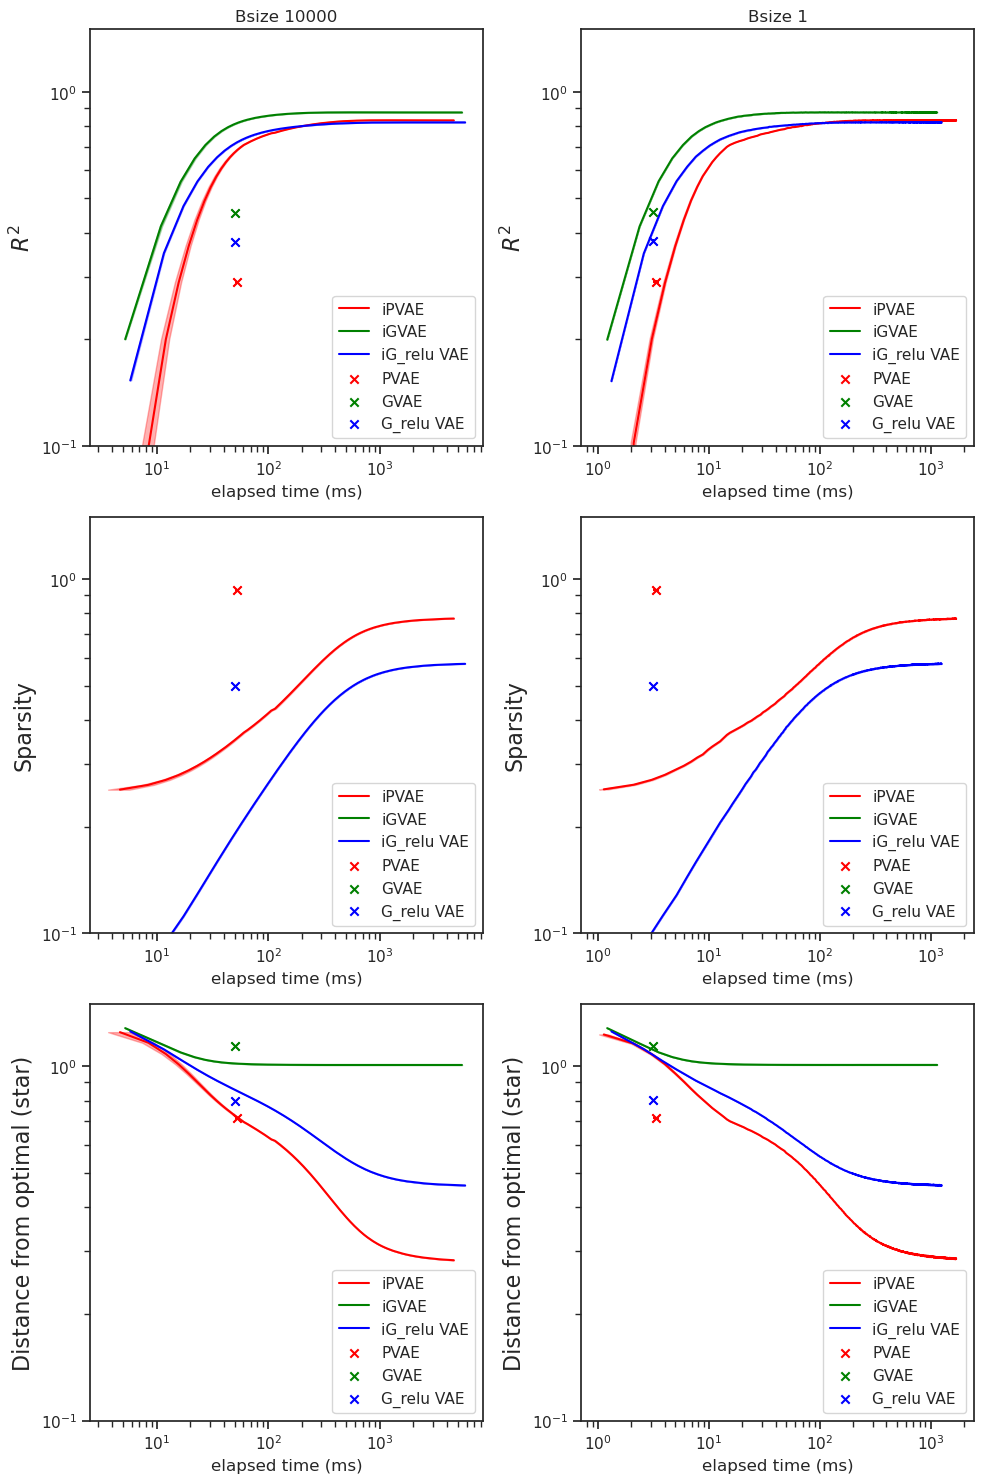

In [19]:

loglog=True
plt.figure(figsize=(2*5, 3*5))
plt.subplot(3, 2, 1)
plt.title("Bsize 10000")
plt.plot(iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0), iterative_bsize10000['r2_all']["poisson"].mean(0), label='iPVAE', color="r")
ste = iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(iterative_bsize10000['r2_all']["poisson"].mean(0),
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0), iterative_bsize10000['r2_all']["gaussian"].mean(0), label='iGVAE', color="g")
ste = iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(iterative_bsize10000['r2_all']["gaussian"].mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), iterative_bsize10000['r2_all']["gaussian+relu"].mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(iterative_bsize10000['r2_all']["gaussian+relu"].mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize10000['timestamps_all']["poisson"].mean(), amortized_bsize10000['r2_all']["poisson"].mean(), label='PVAE', color="r", marker='x')
ste = amortized_bsize10000['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["poisson"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["poisson"].mean(),
             amortized_bsize10000['r2_all']["poisson"].mean(),
             xerr=ste,
             fmt='x', color="r")
    
plt.scatter(amortized_bsize10000['timestamps_all']["gaussian"].mean(), amortized_bsize10000['r2_all']["gaussian"].mean(), label='GVAE', color="g", marker='x')
ste = amortized_bsize10000['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian"].mean(),
             amortized_bsize10000['r2_all']["gaussian"].mean(),
             xerr=ste,
             fmt='x', color="g")

plt.scatter(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(), amortized_bsize10000['r2_all']["gaussian+relu"].mean(), label='G_relu VAE', color="b", marker='x')
ste = amortized_bsize10000['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(),
             amortized_bsize10000['r2_all']["gaussian+relu"].mean(),
             xerr=ste,
             fmt='x', color="b")

if loglog:
    plt.loglog()
plt.xlabel('elapsed time (ms)')
plt.ylabel(r"$R^2$", fontsize=16)
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)


plt.legend()

plt.subplot(3, 2, 3)
plt.plot(iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0), iterative_bsize10000['portion_zeros_all']["poisson"].mean(0), label='iPVAE', color="r")
ste = iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(iterative_bsize10000['portion_zeros_all']["poisson"].mean(0),
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0), iterative_bsize10000['portion_zeros_all']["gaussian"].mean(0), label='iGVAE', color="g")
ste = iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(iterative_bsize10000['portion_zeros_all']["gaussian"].mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), iterative_bsize10000['portion_zeros_all']["gaussian+relu"].mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(iterative_bsize10000['portion_zeros_all']["gaussian+relu"].mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize10000['timestamps_all']["poisson"].mean(), amortized_bsize10000['portion_zeros_all']["poisson"].mean(), label='PVAE', color="r", marker='x')
stex = amortized_bsize10000['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["poisson"].shape[0])
stey = amortized_bsize10000['portion_zeros_all']["poisson"].std() / np.sqrt(amortized_bsize10000['portion_zeros_all']["poisson"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["poisson"].mean(),
             amortized_bsize10000['portion_zeros_all']["poisson"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="r")

plt.scatter(amortized_bsize10000['timestamps_all']["gaussian"].mean(), amortized_bsize10000['portion_zeros_all']["gaussian"].mean(), label='GVAE', color="g", marker='x')
stex = amortized_bsize10000['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian"].shape[0])
stey = amortized_bsize10000['portion_zeros_all']["gaussian"].std() / np.sqrt(amortized_bsize10000['portion_zeros_all']["gaussian"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian"].mean(),
             amortized_bsize10000['portion_zeros_all']["gaussian"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="g")
plt.scatter(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(), amortized_bsize10000['portion_zeros_all']["gaussian+relu"].mean(), label='G_relu VAE', color="b", marker='x')
stex = amortized_bsize10000['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
stey = amortized_bsize10000['portion_zeros_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize10000['portion_zeros_all']["gaussian+relu"].shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(),
             amortized_bsize10000['portion_zeros_all']["gaussian+relu"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="b")

plt.xlabel('elapsed time (ms)')
plt.ylabel('Sparsity', fontsize=16)
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)

if loglog:
    plt.loglog()
plt.legend()

plt.subplot(3, 2, 2)
plt.title("Bsize 1")
plt.plot(iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0), iterative_bsize1['r2_all']["poisson"].mean(0), label='iPVAE', color="r")
ste = iterative_bsize1['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(iterative_bsize1['r2_all']["poisson"].mean(0),
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0), iterative_bsize1['r2_all']["gaussian"].mean(0), label='iGVAE', color="g")
ste = iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(iterative_bsize1['r2_all']["gaussian"].mean(0),
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), iterative_bsize1['r2_all']["gaussian+relu"].mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(iterative_bsize1['r2_all']["gaussian+relu"].mean(0),
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize1['timestamps_all']["poisson"].mean(), amortized_bsize1['r2_all']["poisson"].mean(), label='PVAE', color="r", marker='x')
stex = amortized_bsize1['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize1['timestamps_all']["poisson"].shape[0])
stey = amortized_bsize1['r2_all']["poisson"].std() / np.sqrt(amortized_bsize1['r2_all']["poisson"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["poisson"].mean(),
             amortized_bsize1['r2_all']["poisson"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="r")    

plt.scatter(amortized_bsize1['timestamps_all']["gaussian"].mean(), amortized_bsize1['r2_all']["gaussian"].mean(), label='GVAE', color="g", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian"].shape[0])
stey = amortized_bsize1['r2_all']["gaussian"].std() / np.sqrt(amortized_bsize1['r2_all']["gaussian"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian"].mean(),
             amortized_bsize1['r2_all']["gaussian"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="g")

plt.scatter(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(), amortized_bsize1['r2_all']["gaussian+relu"].mean(), label='G_relu VAE', color="b", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian+relu"].shape[0])
stey = amortized_bsize1['r2_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize1['r2_all']["gaussian+relu"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(),
             amortized_bsize1['r2_all']["gaussian+relu"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="b")

if loglog:
    plt.loglog()
plt.xlabel('elapsed time (ms)')
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)

plt.ylabel(r"$R^2$", fontsize=16)
plt.legend()    

plt.subplot(3, 2, 4)
plt.plot(iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0), iterative_bsize1['portion_zeros_all']["poisson"].mean(0), label='iPVAE', color="r")
ste = iterative_bsize1['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(iterative_bsize1['portion_zeros_all']["poisson"].mean(0),
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0), iterative_bsize1['portion_zeros_all']["gaussian"].mean(0), label='iGVAE', color="g")
ste = iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(iterative_bsize1['portion_zeros_all']["gaussian"].mean(0),
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), iterative_bsize1['portion_zeros_all']["gaussian+relu"].mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(iterative_bsize1['portion_zeros_all']["gaussian+relu"].mean(0),
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize1['timestamps_all']["poisson"].mean(), amortized_bsize1['portion_zeros_all']["poisson"].mean(), label='PVAE', color="r", marker='x')
stex = amortized_bsize1['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize1['timestamps_all']["poisson"].shape[0])
stey = amortized_bsize1['portion_zeros_all']["poisson"].std() / np.sqrt(amortized_bsize1['portion_zeros_all']["poisson"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["poisson"].mean(),
             amortized_bsize1['portion_zeros_all']["poisson"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="r")

plt.scatter(amortized_bsize1['timestamps_all']["gaussian"].mean(), amortized_bsize1['portion_zeros_all']["gaussian"].mean(), label='GVAE', color="g", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian"].shape[0])
stey = amortized_bsize1['portion_zeros_all']["gaussian"].std() / np.sqrt(amortized_bsize1['portion_zeros_all']["gaussian"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian"].mean(),
             amortized_bsize1['portion_zeros_all']["gaussian"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="g")

plt.scatter(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(), amortized_bsize1['portion_zeros_all']["gaussian+relu"].mean(), label='G_relu VAE', color="b", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian+relu"].shape[0])
stey = amortized_bsize1['portion_zeros_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize1['portion_zeros_all']["gaussian+relu"].shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(),
             amortized_bsize1['portion_zeros_all']["gaussian+relu"].mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="b")    

plt.xlabel('elapsed time (ms)')
plt.ylabel('Sparsity', fontsize=16)
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)

if loglog:
    plt.loglog()
plt.legend()

plt.subplot(3, 2, 5)
def perf(x, name):
    portion_zeros = x['portion_zeros_all'][name]
    r2 = x['r2_all'][name].clip(0, 1)
    dist = np.sqrt((1 - r2) ** 2 + (1-portion_zeros) ** 2)
    return dist

plt.plot(iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0), perf(iterative_bsize10000, "poisson").mean(0), label='iPVAE', color="r")
ste = iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(perf(iterative_bsize10000, "poisson").mean(0),
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0), perf(iterative_bsize10000, "gaussian").mean(0), label='iGVAE', color="g")
ste = iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(perf(iterative_bsize10000, "gaussian").mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), perf(iterative_bsize10000, "gaussian+relu").mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(perf(iterative_bsize10000, "gaussian+relu").mean(0),
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize10000['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize10000['timestamps_all']["poisson"].mean(), perf(amortized_bsize10000, "poisson").mean(), label='PVAE', color="r", marker='x')
stex = amortized_bsize10000['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["poisson"].shape[0])
pf = perf(amortized_bsize10000, "poisson")
stey = pf.std() / np.sqrt(pf.shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["poisson"].mean(),
             perf(amortized_bsize10000, "poisson").mean(),
             xerr=stex,
             fmt='x', color="r")    

plt.scatter(amortized_bsize10000['timestamps_all']["gaussian"].mean(), perf(amortized_bsize10000, "gaussian").mean(), label='GVAE', color="g", marker='x')
stex = amortized_bsize10000['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian"].shape[0])
pf = perf(amortized_bsize10000, "gaussian")
stey = pf.std() / np.sqrt(pf.shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian"].mean(),
             perf(amortized_bsize10000, "gaussian").mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="g")

plt.scatter(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(), perf(amortized_bsize10000, "gaussian+relu").mean(), label='G_relu VAE', color="b", marker='x')
stex = amortized_bsize10000['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize10000['timestamps_all']["gaussian+relu"].shape[0])
pf = perf(amortized_bsize10000, "gaussian+relu")
stey = pf.std() / np.sqrt(pf.shape[0])
#error bars
plt.errorbar(amortized_bsize10000['timestamps_all']["gaussian+relu"].mean(),
             perf(amortized_bsize10000, "gaussian+relu").mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="b")

plt.xlabel('elapsed time (ms)')
plt.ylabel('Distance from optimal (star)', fontsize=16)
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)

if loglog:
    plt.loglog()
plt.legend(loc='lower right')

plt.subplot(3, 2, 6)
plt.plot(iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0), perf(iterative_bsize1, "poisson").mean(0), label='iPVAE', color="r")
ste = iterative_bsize1['timestamps_all']["poisson"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["poisson"].shape[0])
plt.fill_betweenx(perf(iterative_bsize1, "poisson").mean(0),
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["poisson"].cumsum(1).mean(0) + ste,
                  color="r", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0), perf(iterative_bsize1, "gaussian").mean(0), label='iGVAE', color="g")
ste = iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian"].shape[0])
plt.fill_betweenx(perf(iterative_bsize1, "gaussian").mean(0),
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian"].cumsum(1).mean(0) + ste,
                  color="g", alpha=0.3)

plt.plot(iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0), perf(iterative_bsize1, "gaussian+relu").mean(0), label='iG_relu VAE', color="b")
ste = iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).std(0) / np.sqrt(iterative_bsize1['timestamps_all']["gaussian+relu"].shape[0])
plt.fill_betweenx(perf(iterative_bsize1, "gaussian+relu").mean(0),
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) - ste,
                  iterative_bsize1['timestamps_all']["gaussian+relu"].cumsum(1).mean(0) + ste,
                  color="b", alpha=0.3)

plt.scatter(amortized_bsize1['timestamps_all']["poisson"].mean(), perf(amortized_bsize1, "poisson").mean(), label='PVAE', color="r", marker='x')
stex = amortized_bsize1['timestamps_all']["poisson"].std() / np.sqrt(amortized_bsize1['timestamps_all']["poisson"].shape[0])
pf = perf(amortized_bsize1, "poisson")
stey = pf.std() / np.sqrt(pf.shape[0])
# error bars
plt.errorbar(amortized_bsize1['timestamps_all']["poisson"].mean(),
             perf(amortized_bsize1, "poisson").mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="r")

plt.scatter(amortized_bsize1['timestamps_all']["gaussian"].mean(), perf(amortized_bsize1, "gaussian").mean(), label='GVAE', color="g", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian"].shape[0])
pf = perf(amortized_bsize1, "gaussian")
stey = pf.std() / np.sqrt(pf.shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian"].mean(),
             perf(amortized_bsize1, "gaussian").mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="g")

plt.scatter(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(), perf(amortized_bsize1, "gaussian+relu").mean(), label='G_relu VAE', color="b", marker='x')
stex = amortized_bsize1['timestamps_all']["gaussian+relu"].std() / np.sqrt(amortized_bsize1['timestamps_all']["gaussian+relu"].shape[0])
pf = perf(amortized_bsize1, "gaussian+relu")
stey = pf.std() / np.sqrt(pf.shape[0])
#error bars
plt.errorbar(amortized_bsize1['timestamps_all']["gaussian+relu"].mean(),
             perf(amortized_bsize1, "gaussian+relu").mean(),
             xerr=stex,
             yerr=stey,
             fmt='x', color="b")
if loglog:
    plt.loglog()
plt.ylim(-1e-1 if not loglog else 1e-1, 1.5)
plt.xlabel('elapsed time (ms)')
plt.ylabel('Distance from optimal (star)', fontsize=16)

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# %%


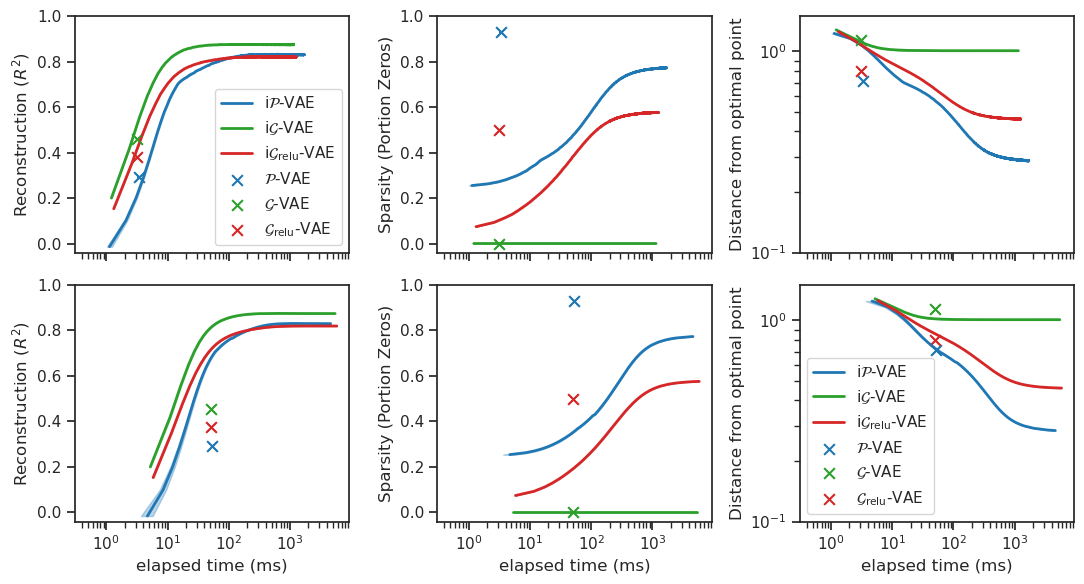